In [22]:
import json
import os
import pandas as pd
import requests
import argparse
from datetime import datetime, timezone
from datetime import timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


In [23]:
_config_path = os.path.join(os.path.dirname(os.path.abspath("__file__")), "forecasts.json")
with open(_config_path, encoding="utf-8") as _f:
    fcst_dict = json.load(_f)


In [24]:
'''
parser = argparse.ArgumentParser(
                    prog='download forcing data for bulletin',
                    description='Downloads forcing data for bulletin',
                    epilog='Jose Valles, DINAGUA, 15062026')

#
parser.add_argument('cuenca', help='provide the name of the basin for which you want to download the data')
parser.add_argument('localidad', help='provide the location for which you want to download the data')

args = parser.parse_args()
'''

args = argparse.Namespace(
    cuenca ='Cebollati',
    localidad ='Paso Averias'
)


In [25]:
# convert the arguments to uppercase
args.cuenca = args.cuenca.upper()
args.localidad = args.localidad.upper()

In [26]:
cfg = fcst_dict[args.cuenca][args.localidad]
cfg

{'pronostico': {'locationIds': 'CebollatiAverias',
  'parameterIds': 'Q.for',
  'moduleInstanceIds': 'POST_CebollatiAverias_GFS'},
 'simulado': {'locationIds': 'CebollatiAverias',
  'parameterIds': 'Q.sim',
  'moduleInstanceIds': 'POST_CebollatiAverias_Update'},
 'observado': {'locationIds': '15.0',
  'parameterIds': 'Q.obs',
  'moduleInstanceIds': 'PreprocessQ'},
 'umbrales': {'aviso': 1296, 'seguridad': 1991, 'sensible': 2892},
 'nombre': 'Río Cebollatí'}

In [27]:
URL_BASE = "http://prodterh-fssaws:8080/FewsWebServices/rest/fewspiservice/v1/timeseries"

In [28]:
# obtener la fecha y hora de hoy en formato UTC
fecha_hoy = datetime.now(timezone.utc).strftime('%Y-%m-%dT%H:%M:%SZ')
print(f"la fecha de hoy es: {fecha_hoy}")
print("----------------------------------")

# obtener 5 dias antes y 5 días después de la fecha de hoy en formato UTC
fecha_inicio = (datetime.now(timezone.utc) - timedelta(days=5)).strftime('%Y-%m-%dT%H:%M:%SZ')
fecha_fin = (datetime.now(timezone.utc) + timedelta(days=5)).strftime('%Y-%m-%dT%H:%M:%SZ')
print(f"la fecha de inicio es: {fecha_inicio}")
print(f"la fecha de fin es: {fecha_fin}")

la fecha de hoy es: 2026-08-14T18:49:48Z
----------------------------------
la fecha de inicio es: 2026-08-09T18:49:48Z
la fecha de fin es: 2026-08-19T18:49:48Z


In [29]:
data_dict = {}
section = ['pronostico', 'simulado', 'observado']

with requests.Session() as session:
    for sec in section:
        params = dict(
            documentFormat="PI_JSON",
            locationIds=cfg[sec]['locationIds'],
            parameterIds=cfg[sec]['parameterIds'],
            moduleInstanceIds=cfg[sec]['moduleInstanceIds'],
            startTime=fecha_inicio,
            endTime=fecha_fin
        )
        response = session.get(url=URL_BASE, params=params)
        if response.status_code == 200:
            data = response.json()
        else:
            print(f"Error {response.status_code} for section {sec}: {response.text}")
            data_dict[sec] = []
            continue
        timeSeries = data.get('timeSeries', [])
        if not timeSeries:
            print(f"No timeSeries data returned for section {sec}")
        data_dict[sec] = timeSeries


No timeSeries data returned for section observado


In [30]:
df_dict = {}
for sec, ts_list in data_dict.items():
    if not ts_list:
        df_dict[sec] = pd.DataFrame(columns=['datetime', 'value', 'flag'])
        continue
    events = ts_list[0]['events']
    miss_val = float(ts_list[0]['header']['missVal'])
    df = pd.DataFrame(events)
    df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'])
    # the datetime is in UTC, so need to substract 3 hours using timedelta
    df['datetime'] = df['datetime'] - timedelta(hours=3)
    df['value'] = pd.to_numeric(df['value']).replace(miss_val, float('nan'))
    df['flag'] = df['flag'].astype(int)
    df_dict[sec] = df[['datetime', 'value', 'flag']].set_index('datetime')

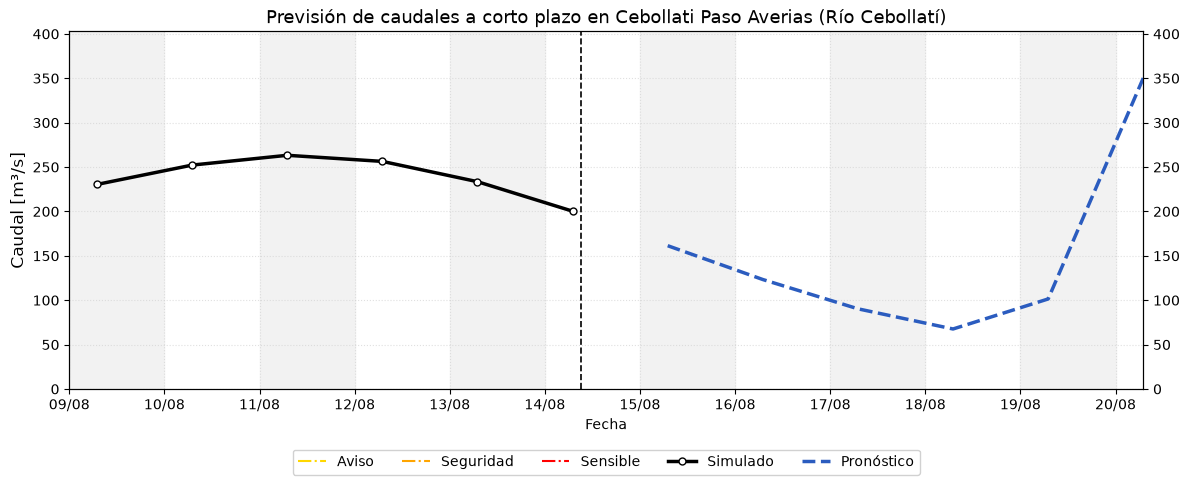

In [31]:

# if df_sim and df_fcst and df_obs are empty, print a message and exit
if df_dict['simulado'].empty and df_dict['pronostico'].empty and df_dict['observado'].empty:
    print(f"No data available for {args.cuenca} - {args.localidad}")
else:
    df_sim  = df_dict['simulado']
    df_fcst = df_dict['pronostico']
    df_obs  = df_dict['observado']

    # Metadata from FORECAST header
    fcst_header   = data_dict['pronostico'][0]['header'] if data_dict['pronostico'] else {}
    location_name = fcst_header.get('stationName', args.localidad)
    units         = fcst_header.get('units', '')
    units = units.replace('3', '³')

    # t0: model initialization time → vertical divider
    fd = fcst_header.get('forecastDate', {})
    t0 = pd.Timestamp(f"{fd['date']} {fd['time']}") - timedelta(hours=3) if fd else df_sim.dropna().index[-1]

    fig, ax = plt.subplots(figsize=(12, 5), dpi=100)

    # Alternating daily background stripes
    x_start = min(df_sim.index.min(), df_fcst.index.min()).normalize()
    x_end   = max(df_sim.index.max(), df_fcst.index.max())
    day, i = x_start, 0
    while day <= x_end:
        if i % 2 == 0:
            ax.axvspan(day, day + pd.Timedelta(days=1), color='#f2f2f2', zorder=0)
        day += pd.Timedelta(days=1)
        i   += 1

    ax.grid(True, which='both', linestyle=':', color='lightgrey', alpha=0.7, zorder=1)

    # Threshold horizontal lines
    umbral_styles = {
        'aviso':     ('gold',   'Aviso'),
        'seguridad': ('orange', 'Seguridad'),
        'sensible':  ('red',    'Sensible'),
        'extrema':   ('purple', 'Extrema'),
    }
    umbrales = cfg.get('umbrales', {})
    for key, (color, label) in umbral_styles.items():
        val = umbrales.get(key)
        if val is not None:
            ax.axhline(y=val, color=color, linestyle='-.', linewidth=1.5, label=label, zorder=2)

    # Vertical divider between past simulation and forecast
    ax.axvline(x=t0, color='black', linestyle='--', linewidth=1.2, zorder=2)

    # --- Series ---
    if not df_obs.empty:
        ax.plot(df_obs.index, df_obs['value'], color='black', linewidth=0.8,
                marker='o', markersize=4, label='Observado', zorder=5)

    if not df_sim.empty:
        ax.plot(df_sim.index, df_sim['value'], color='#000000', linewidth=2.5,
                marker='o', markersize=5, label='Simulado', zorder=4,
                markerfacecolor='white', markeredgecolor='#000000')

    if not df_fcst.empty:
        ax.plot(df_fcst.index, df_fcst['value'], color='#2b5cbf', linewidth=2.5,
                linestyle='--', label='Pronóstico', zorder=3)

    # Y limits: bottom=0, top based on max value across all series
    max_vals = [s['value'].max() for s in [df_sim, df_fcst, df_obs] if not s.empty]

    # Set a fixed y_max value of 2000 instead of calculating it dynamically
    y_max = max(max_vals) * 1.15 if max_vals else 1
    # y_max = 2000

    ax.set_ylim(0, y_max)

    # Axes and labels
    ax.set_title(f'Previsión de caudales a corto plazo en {location_name} ({cfg["nombre"]})', fontsize=13)
    ax.set_ylabel(f'Caudal [{units}]', fontsize=12)
    ax.set_xlabel('Fecha', fontsize=10)
    ax.set_xlim(x_start, x_end)

    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
    ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))

    # Duplicate Y axis on the right
    ax2 = ax.twinx()
    ax2.set_ylim(ax.get_ylim())

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.15),
              framealpha=0.9, ncol=len(handles), bbox_transform=ax.transAxes)
    plt.tight_layout()
    plt.show()
